In [1]:
import re
import numpy as np
from collections import defaultdict

# Dataset: (text, label)
documents = [
    ("I love programming in Python", "positive"),
    ("Python is a great programming language", "positive"),
    ("I dislike bugs in the code", "negative"),
    ("Debugging is a frustrating task", "negative"),
    ("I enjoy learning new algorithms", "positive"),
    ("Bugs and errors make me angry", "negative"),
]

# Step 1: Preprocessing
stopwords = set(["is", "a", "in", "the", "and", "me", "i"])

def preprocess(text):
    text = text.lower()
    tokens = re.findall(r'\b\w+\b', text)
    tokens = [word for word in tokens if word not in stopwords]
    return tokens

# Step 2: Vocabulary and Bag of Words
vocab = set()
processed_docs = []

for doc, label in documents:
    tokens = preprocess(doc)
    vocab.update(tokens)
    processed_docs.append((tokens, label))

vocab = sorted(list(vocab))
vocab_index = {word: i for i, word in enumerate(vocab)}

def vectorize(tokens):
    vec = np.zeros(len(vocab))
    for token in tokens:
        if token in vocab_index:
            vec[vocab_index[token]] += 1
    return vec

X = np.array([vectorize(tokens) for tokens, _ in processed_docs])
y = np.array([1 if label == "positive" else 0 for _, label in processed_docs])


In [2]:
def train_naive_bayes(X, y):
    n_docs, n_words = X.shape
    class0_count = np.sum(y == 0)
    class1_count = np.sum(y == 1)

    prior_0 = class0_count / n_docs
    prior_1 = class1_count / n_docs

    word_counts_0 = np.ones(n_words)  # Laplace smoothing
    word_counts_1 = np.ones(n_words)
    total_words_0 = n_words
    total_words_1 = n_words

    for i in range(n_docs):
        if y[i] == 0:
            word_counts_0 += X[i]
            total_words_0 += np.sum(X[i])
        else:
            word_counts_1 += X[i]
            total_words_1 += np.sum(X[i])

    cond_prob_0 = word_counts_0 / total_words_0
    cond_prob_1 = word_counts_1 / total_words_1

    return prior_0, prior_1, cond_prob_0, cond_prob_1

def predict_naive_bayes(X, prior_0, prior_1, cond_prob_0, cond_prob_1):
    predictions = []
    for x in X:
        log_prob_0 = np.log(prior_0) + np.sum(np.log(cond_prob_0) * x)
        log_prob_1 = np.log(prior_1) + np.sum(np.log(cond_prob_1) * x)
        predictions.append(1 if log_prob_1 > log_prob_0 else 0)
    return np.array(predictions)

# Train and test
prior_0, prior_1, cond_prob_0, cond_prob_1 = train_naive_bayes(X, y)
y_pred_nb = predict_naive_bayes(X, prior_0, prior_1, cond_prob_0, cond_prob_1)
accuracy_nb = np.mean(y_pred_nb == y)
print("Naive Bayes Accuracy:", accuracy_nb)


Naive Bayes Accuracy: 1.0


In [3]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def train_logistic_regression(X, y, lr=0.1, epochs=1000):
    n_samples, n_features = X.shape
    weights = np.zeros(n_features)
    bias = 0

    for _ in range(epochs):
        linear_model = np.dot(X, weights) + bias
        predictions = sigmoid(linear_model)

        dw = (1 / n_samples) * np.dot(X.T, (predictions - y))
        db = (1 / n_samples) * np.sum(predictions - y)

        weights -= lr * dw
        bias -= lr * db

    return weights, bias

def predict_logistic_regression(X, weights, bias):
    linear_model = np.dot(X, weights) + bias
    predictions = sigmoid(linear_model)
    return np.array([1 if p > 0.5 else 0 for p in predictions])

# Train and test
weights, bias = train_logistic_regression(X, y)
y_pred_lr = predict_logistic_regression(X, weights, bias)
accuracy_lr = np.mean(y_pred_lr == y)
print("Logistic Regression Accuracy:", accuracy_lr)


Logistic Regression Accuracy: 1.0


**Train-Test**

Naive Bayes Accuracy: 0.0
Naive Bayes Confusion Matrix:
 [[0 2]
 [0 0]]

Logistic Regression Accuracy: 0.0
Logistic Regression Confusion Matrix:
 [[0 2]
 [0 0]]


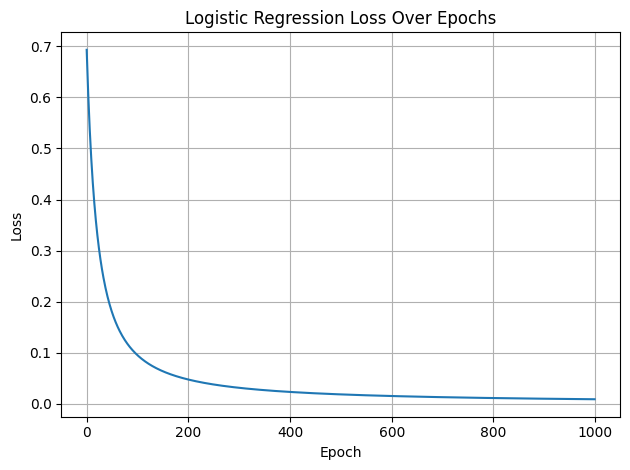

In [4]:
import re
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Sample dataset
documents = [
    ("I love programming in Python", "positive"),
    ("Python is a great programming language", "positive"),
    ("I dislike bugs in the code", "negative"),
    ("Debugging is a frustrating task", "negative"),
    ("I enjoy learning new algorithms", "positive"),
    ("Bugs and errors make me angry", "negative"),
]

# Preprocessing
stopwords = set(["is", "a", "in", "the", "and", "me", "i"])

def preprocess(text):
    text = text.lower()
    tokens = re.findall(r'\b\w+\b', text)
    return [t for t in tokens if t not in stopwords]

vocab = set()
processed_docs = []
for doc, label in documents:
    tokens = preprocess(doc)
    vocab.update(tokens)
    processed_docs.append((tokens, label))

vocab = sorted(list(vocab))
vocab_index = {word: i for i, word in enumerate(vocab)}

def vectorize(tokens):
    vec = np.zeros(len(vocab))
    for token in tokens:
        if token in vocab_index:
            vec[vocab_index[token]] += 1
    return vec

X = np.array([vectorize(tokens) for tokens, _ in processed_docs])
y = np.array([1 if label == "positive" else 0 for _, label in processed_docs])

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Naive Bayes
def train_naive_bayes(X, y):
    n_docs, n_words = X.shape
    class0_count = np.sum(y == 0)
    class1_count = np.sum(y == 1)
    prior_0 = class0_count / n_docs
    prior_1 = class1_count / n_docs

    word_counts_0 = np.ones(n_words)
    word_counts_1 = np.ones(n_words)
    total_words_0 = n_words
    total_words_1 = n_words

    for i in range(n_docs):
        if y[i] == 0:
            word_counts_0 += X[i]
            total_words_0 += np.sum(X[i])
        else:
            word_counts_1 += X[i]
            total_words_1 += np.sum(X[i])

    cond_prob_0 = word_counts_0 / total_words_0
    cond_prob_1 = word_counts_1 / total_words_1

    return prior_0, prior_1, cond_prob_0, cond_prob_1

def predict_naive_bayes(X, prior_0, prior_1, cond_prob_0, cond_prob_1):
    predictions = []
    for x in X:
        log_prob_0 = np.log(prior_0) + np.sum(np.log(cond_prob_0) * x)
        log_prob_1 = np.log(prior_1) + np.sum(np.log(cond_prob_1) * x)
        predictions.append(1 if log_prob_1 > log_prob_0 else 0)
    return np.array(predictions)

prior_0, prior_1, cond_prob_0, cond_prob_1 = train_naive_bayes(X_train, y_train)
y_pred_nb = predict_naive_bayes(X_test, prior_0, prior_1, cond_prob_0, cond_prob_1)

# Logistic Regression
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def train_logistic_regression(X, y, lr=0.1, epochs=1000):
    n_samples, n_features = X.shape
    weights = np.zeros(n_features)
    bias = 0
    loss_history = []

    for _ in range(epochs):
        linear_model = np.dot(X, weights) + bias
        predictions = sigmoid(linear_model)

        loss = -np.mean(y * np.log(predictions + 1e-8) + (1 - y) * np.log(1 - predictions + 1e-8))
        loss_history.append(loss)

        dw = (1 / n_samples) * np.dot(X.T, (predictions - y))
        db = (1 / n_samples) * np.sum(predictions - y)

        weights -= lr * dw
        bias -= lr * db

    return weights, bias, loss_history

def predict_logistic_regression(X, weights, bias):
    linear_model = np.dot(X, weights) + bias
    predictions = sigmoid(linear_model)
    return np.array([1 if p > 0.5 else 0 for p in predictions])

weights, bias, loss_history = train_logistic_regression(X_train, y_train)
y_pred_lr = predict_logistic_regression(X_test, weights, bias)

# Accuracy
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

# Confusion matrix
def confusion_matrix(y_true, y_pred):
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    return np.array([[TP, FN], [FP, TN]])

# Print results
print("Naive Bayes Accuracy:", accuracy(y_test, y_pred_nb))
print("Naive Bayes Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))
print("\nLogistic Regression Accuracy:", accuracy(y_test, y_pred_lr))
print("Logistic Regression Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))

# Plot Loss
plt.plot(loss_history)
plt.title("Logistic Regression Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.tight_layout()
plt.show()
